In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, RobertaModel, RobertaTokenizer
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.cluster import DBSCAN
from sklearn.utils.class_weight import compute_class_weight
import openai
import json

In [ ]:
from google.colab import drive
drive.mount('/content/drive/',force_remount=False)

Mounted at /content/drive/


In [ ]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part4 feature-engineering/leetcode_questions_df.csv')

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            61834 non-null  object 
 1   country                             61834 non-null  object 
 2   contest_url                         61834 non-null  object 
 3   num_of_contest                      61834 non-null  int64  
 4   is_weekly                           61834 non-null  bool   
 5   rank                                61834 non-null  int64  
 6   score                               61834 non-null  int64  
 7   question_number                     61834 non-null  int64  
 8   question_language                   61834 non-null  object 
 9   question_code                       61834 non-null  object 
 10  number_of_lines                     61834 non-null  int64  
 11  names_set                           61834

In [ ]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'java']
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_number'] > 2]
leetcode_questions_df = leetcode_questions_df.drop_duplicates(subset=['question_code'])

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2999 entries, 20 to 61821
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            2999 non-null   object 
 1   country                             2999 non-null   object 
 2   contest_url                         2999 non-null   object 
 3   num_of_contest                      2999 non-null   int64  
 4   is_weekly                           2999 non-null   bool   
 5   rank                                2999 non-null   int64  
 6   score                               2999 non-null   int64  
 7   question_number                     2999 non-null   int64  
 8   question_language                   2999 non-null   object 
 9   question_code                       2999 non-null   object 
 10  number_of_lines                     2999 non-null   int64  
 11  names_set                           2999 non-n

<Axes: >

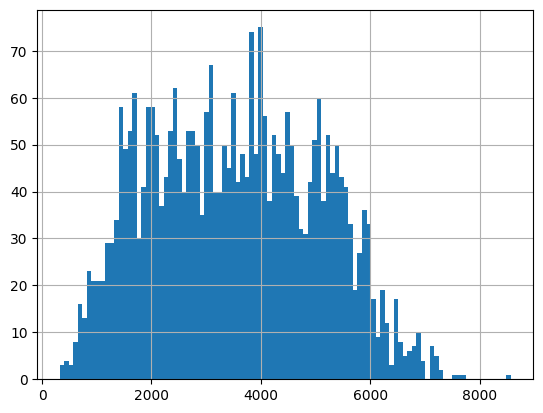

In [ ]:
leetcode_questions_df.contest_finish_time_total_seconds.hist(bins=100)

In [ ]:
# Define rank thresholds
percantage = 10

high_rank_threshold = leetcode_questions_df['contest_finish_time_total_seconds'].quantile(percantage/100)
low_rank_threshold = leetcode_questions_df['contest_finish_time_total_seconds'].quantile(1 - percantage/100)


leetcode_questions_df["experienced_programmer"] = leetcode_questions_df["contest_finish_time_total_seconds"] <= low_rank_threshold


high_rank_df = leetcode_questions_df[leetcode_questions_df["contest_finish_time_total_seconds"] < high_rank_threshold]
low_rank_df = leetcode_questions_df[leetcode_questions_df["contest_finish_time_total_seconds"] > low_rank_threshold]


filtered_df = pd.concat([high_rank_df, low_rank_df])

filtered_df.reset_index(drop=True, inplace=True)

filtered_df["experienced_programmer"].value_counts()

,count
experienced_programmer,
True,300
False,300


In [ ]:
leetcode_questions_df = filtered_df

In [ ]:
leetcode_questions_df.describe()

,num_of_contest,rank,score,question_number,number_of_lines,token_count,variables_count,function_count,loop_count,condition_count,...,function_density,loop_density,condition_density,comment_tokens_density,contest_finish_time_total_seconds,question_finish_time_total_seconds,time_spent_per_question,global_rank_percentile,question_code_length,num_contests_participated
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.00000,600.000000,600.000000,...,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,284.626667,606.956667,15.291667,3.320000,74.673333,46.781667,25.520000,4.06500,4.800000,6.593333,...,0.051564,0.087768,0.110414,0.088365,3632.128333,2479.851667,1180.896667,0.024536,2159.198333,10.588333
std,125.305772,344.768619,3.105802,0.466865,265.088765,63.031624,36.307989,19.87618,13.570812,22.666073,...,0.037712,0.063429,0.071215,0.168463,2527.617146,1774.466462,1107.251725,0.079768,7660.892041,9.365275
min,116.000000,1.000000,8.000000,3.000000,8.000000,11.000000,5.000000,1.00000,0.000000,0.000000,...,0.006993,0.000000,0.000000,0.000000,326.000000,179.000000,0.000000,0.000001,109.000000,1.000000
25%,124.000000,343.750000,12.000000,3.000000,29.000000,30.000000,16.000000,1.00000,2.000000,2.000000,...,0.030303,0.045285,0.058824,0.000000,1191.750000,1016.500000,366.500000,0.000266,856.500000,3.000000
50%,372.000000,631.500000,17.000000,3.000000,42.000000,37.000000,20.000000,2.00000,3.000000,4.000000,...,0.043478,0.078947,0.100000,0.000000,3532.000000,1462.000000,725.000000,0.001755,1230.500000,7.000000
75%,383.000000,880.000000,18.000000,4.000000,60.000000,46.000000,26.000000,2.00000,5.000000,6.000000,...,0.061224,0.115385,0.150000,0.115135,5981.000000,4481.500000,1745.750000,0.012281,1722.000000,17.000000
max,390.000000,1224.000000,19.000000,4.000000,2770.000000,655.000000,383.000000,208.00000,144.000000,250.000000,...,0.320988,0.521739,0.457143,0.859155,8568.000000,5391.000000,5219.000000,0.828094,80163.000000,34.000000


In [ ]:
X=leetcode_questions_df.drop('experienced_programmer',axis=1)
Y=leetcode_questions_df.experienced_programmer.astype(int)

In [ ]:
X_train_text, X_test_text, Y_train, y_test = train_test_split(X.question_code, Y, test_size=0.2, random_state=0,stratify=Y)

In [ ]:
X_train_text, X_valid_text, y_train, y_valid = train_test_split(X_train_text, Y_train, test_size=0.125, random_state=0,stratify=Y_train)

In [ ]:
df = pd.concat([X_train_text, y_train], axis=1)

system_prompt = "You are a code reviewer. Determine if the following code was written by an experienced programmer. Respond with 'Yes' or 'No'."

conversations = []

for _, row in df.iterrows():
    user_message = f"Here is the code:\n\n{row['question_code']}\n\nIs this written by an experienced programmer?"
    assistant_response = "Yes" if row["experienced_programmer"] == 1 else "No"

    conversation = {
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_message},
            {"role": "assistant", "content": assistant_response}
        ]
    }
    conversations.append(conversation)

with open("training_data.jsonl", "w") as f:
    for convo in conversations:
        f.write(json.dumps(convo) + "\n")


In [ ]:
df = pd.concat([X_valid_text, y_valid], axis=1)

system_prompt = "You are a code reviewer. Determine if the following code was written by an experienced programmer. Respond with 'Yes' or 'No'."

conversations = []

for _, row in df.iterrows():
    user_message = f"Here is the code:\n\n{row['question_code']}\n\nIs this written by an experienced programmer?"
    assistant_response = "Yes" if row["experienced_programmer"] == 1 else "No"

    conversation = {
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_message},
            {"role": "assistant", "content": assistant_response}
        ]
    }
    conversations.append(conversation)

# Write the conversations to a JSONL file
with open("validation_data.jsonl", "w") as f:
    for convo in conversations:
        f.write(json.dumps(convo) + "\n")

# Finetuned GPT 4 nano

In [ ]:

MODEL_NAME = "ft:gpt-4.1-nano-2025-04-14:personal:java-expericence:BcxXtD29"
API_KEY = ""

client = openai.OpenAI(api_key=API_KEY)

In [ ]:
def get_finetuned_llm_prediction(code):
  response = client.chat.completions.create(
      model=MODEL_NAME,
      messages=[
                  {"role": "system", "content": "You are a code reviewer. Determine if the following code was written by an experienced programmer. Respond with 'Yes' or 'No'."},
                  {"role": "user", "content": f"Here is the code:\n\n{code}\n\nIs this written by an experienced programmer?"}
               ],
  )

  return {"Yes": 1, "No": 0}[response.choices[0].message.content]

In [ ]:
y_test_llm = X_test_text.apply(get_finetuned_llm_prediction)

              precision    recall  f1-score   support

    low_rank       0.79      0.88      0.83        60
   high_rank       0.87      0.77      0.81        60

    accuracy                           0.82       120
   macro avg       0.83      0.82      0.82       120
weighted avg       0.83      0.82      0.82       120

f1_score_macro :  0.8244024806633684
f1_score_weighted :  0.8244024806633684


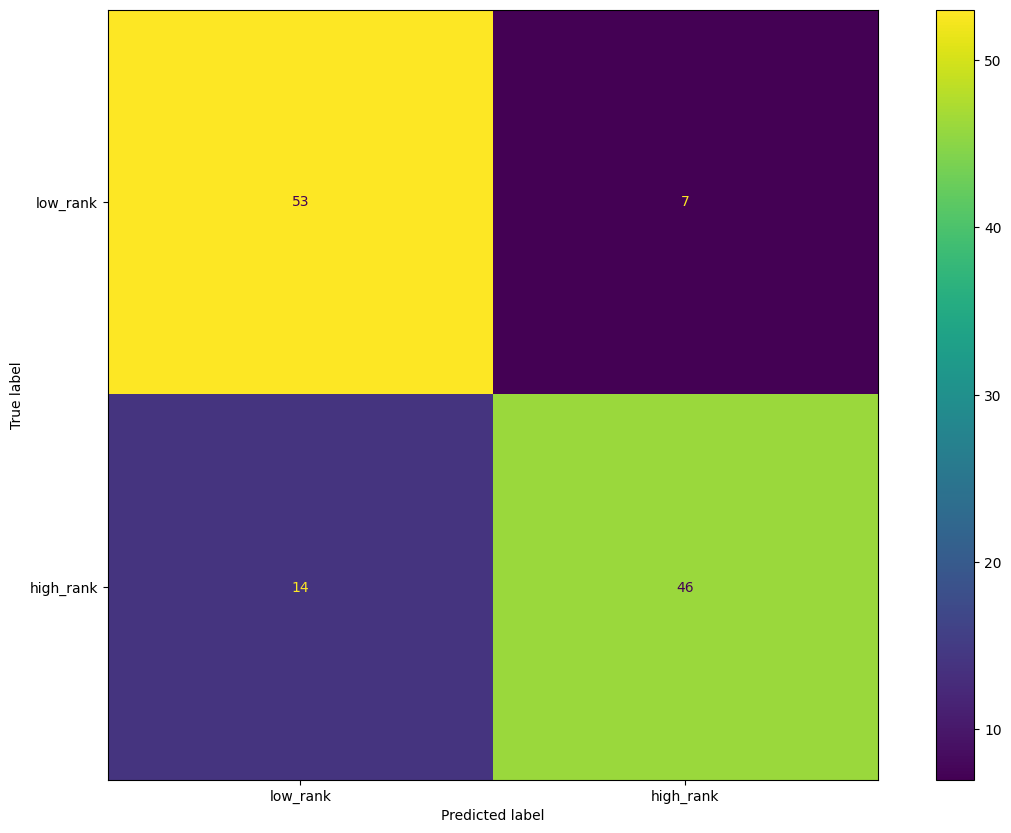

In [ ]:
print(classification_report(y_test, y_test_llm, target_names=['low_rank','high_rank']))

print("f1_score_macro : ",f1_score(y_test, y_test_llm, average='macro'))
print("f1_score_weighted : ",f1_score(y_test, y_test_llm, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_llm), display_labels=['low_rank','high_rank'])

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()